In [88]:
from sklearn.datasets import load_iris
import pandas as pd

df = pd.DataFrame(load_iris().data, columns=load_iris().feature_names)
target = load_iris().target

target = target

print("-"*100)
print("Iris Dataset")
print(df.head())

print("-"*100)
print("Target Values")
print(target[:5])

print("-"*100)
print("Unique Target Classes")
print(set(target))

----------------------------------------------------------------------------------------------------
Iris Dataset
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2
----------------------------------------------------------------------------------------------------
Target Values
[0 0 0 0 0]
----------------------------------------------------------------------------------------------------
Unique Target Classes
{np.int64(0), np.int64(1), np.int64(2)}


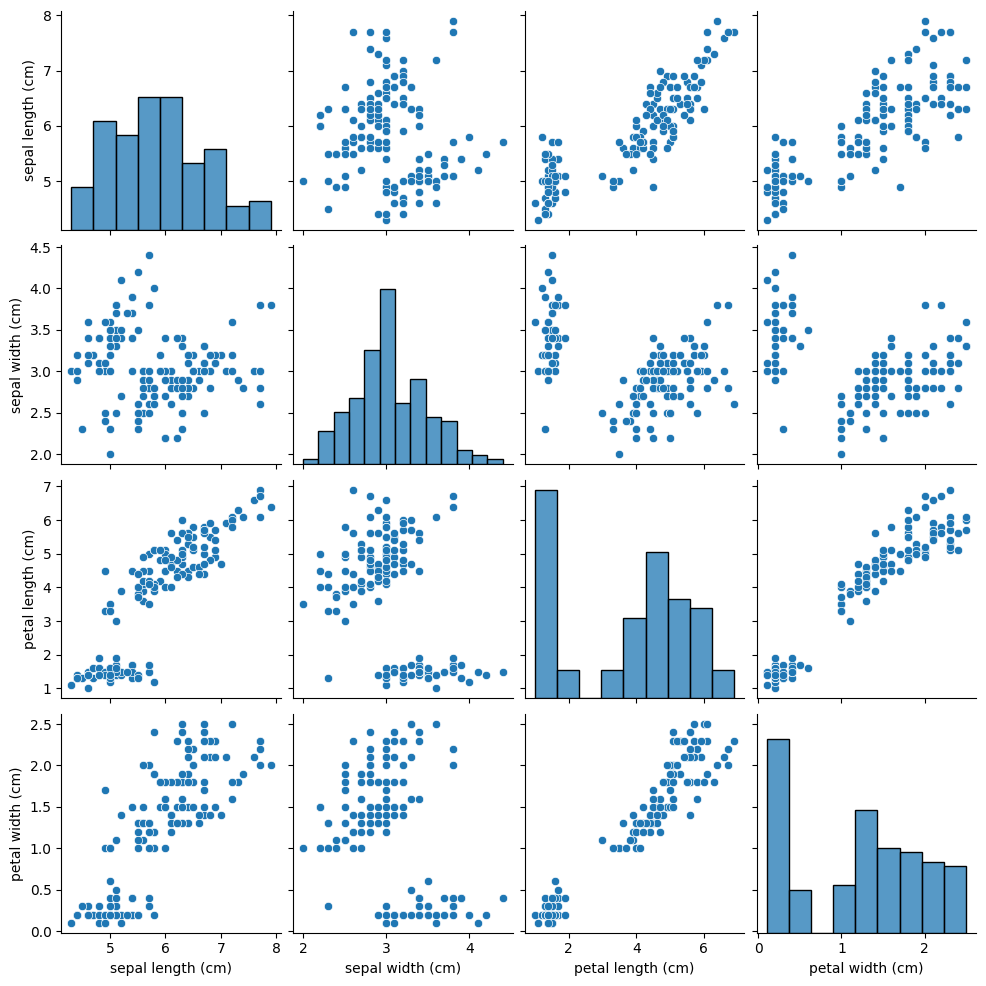

In [89]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.pairplot(df)
plt.show()

In [90]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df, target, test_size=0.2, stratify=target, random_state=42)


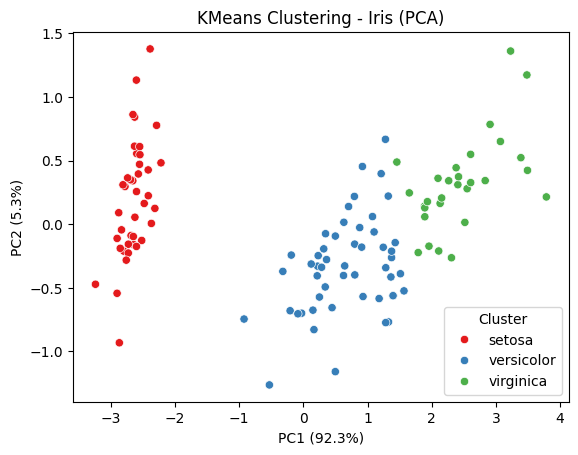

In [ ]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

model = KMeans(n_clusters=3, init='k-means++', n_init=10, random_state=42)
model.fit(X_train)

cluster_names = {0: 'setosa', 1: 'versicolor', 2: 'virginica'}
labels_named = pd.Series(model.labels_).map(cluster_names)

#PCA serve a ridurre il numero di dimensioni di un dataset mantenendo quanta più informazione possibile.
#Prende le feature originali e le ricombina in nuove componenti sintetiche ordinate per varianza spiegata. Non seleziona feature, ne crea di nuove.
pca = PCA(n_components=2)
X_train_2d = pca.fit_transform(X_train)

sns.scatterplot(
    x=X_train_2d[:, 0],
    y=X_train_2d[:, 1],
    hue=labels_named,
    palette='Set1'
)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.title("KMeans Clustering - Iris (PCA)")
plt.legend(title="Cluster")
plt.show()

In [92]:
from sklearn.metrics import silhouette_score

labels_train = model.labels_
labels_test  = model.predict(X_test)  # proietta sui centroidi già trovati

# Train
print("TRAIN:")
print(f"  Silhouette={silhouette_score(X_train, labels_train):.3f}")

# Test
print("TEST:")
print(f"  Silhouette={silhouette_score(X_test, labels_test):.3f}")

TRAIN:
  Silhouette=0.573
TEST:
  Silhouette=0.489


# Silhouette Score

## Cos'è

Una metrica che misura **quanto bene ogni punto appartiene al suo cluster** rispetto agli altri cluster. Combina due concetti in un unico valore:

- **Coesione**: quanto il punto è vicino agli altri punti del *suo* cluster
- **Separazione**: quanto il punto è lontano dai punti del cluster *più vicino*

---

## Formula

Per ogni punto i:

s(i) = ( b(i) - a(i) ) / max( a(i), b(i) )

Dove:

- a(i) = distanza media di i da tutti gli altri punti **nel suo cluster** (coesione)
- b(i) = distanza media di i da tutti i punti del **cluster più vicino** (separazione)

Il **Silhouette Score globale** è la media di s(i) su tutti i punti.

---

## Range e interpretazione

| Valore | Significato |
|---|---|
| vicino a +1 | Il punto è ben dentro il suo cluster e lontano dagli altri |
| vicino a 0 | Il punto è sul confine tra due cluster |
| vicino a -1 | Il punto è probabilmente assegnato al cluster sbagliato |

### Fasce pratiche

| Range | Interpretazione |
|---|---|
| > 0.70 | Struttura forte |
| 0.50 - 0.70 | Struttura ragionevole |
| 0.25 - 0.50 | Struttura debole |
| < 0.25 | Nessuna struttura reale |

---

## Esempio visivo

Cluster ben separati:

  [A A A]      [B B B]      [C C C]
  a(i) basso   b(i) alto   → s(i) vicino a +1

Cluster sovrapposti:

  [A A B A]    [B A B B]
  a(i) alto    b(i) basso  → s(i) vicino a 0 o negativo

---

## Come si usa in sklearn

from sklearn.metrics import silhouette_score
score = silhouette_score(X, labels)
print(f"Silhouette Score: {score:.3f}")

## Limite principale

- Costo computazionale O(n²) → lento su dataset grandi
- Assume che la distanza euclidea sia significativa → funziona bene con cluster sferici (K-Means), meno con forme arbitrarie

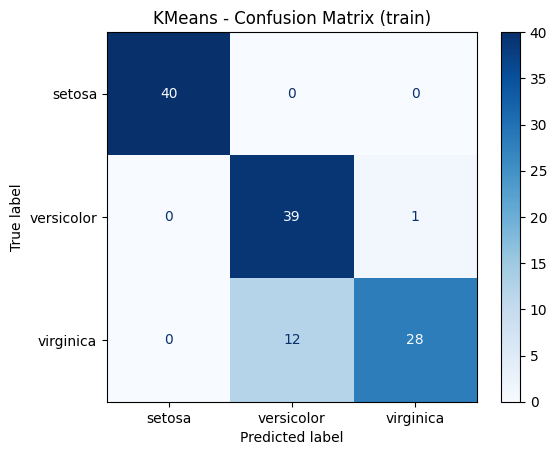

In [94]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Confusion matrix
cm = confusion_matrix(y_train, model.labels_)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['setosa', 'versicolor', 'virginica']
)
disp.plot(cmap='Blues')
plt.title("KMeans - Confusion Matrix (train)")
plt.show()